# Inspect task and sample outputs

In [ ]:
import json

In [2]:
import os
if not os.path.isdir("eai_starter_kit"):
    import gdown
    gdown.download("https://drive.google.com/uc?id=1KGUIGetLaizLTzWqXdR8WlMTwKUpYJQa", "eai_starter_kit.zip", quiet=False)
    os.system("unzip eai_starter_kit.zip && rm eai_starter_kit.zip")

In [3]:
envs = ["behavior", "virtualhome"]
env = envs[0]

In [4]:
tasks = ["goal_interpretation", "subgoal_decomposition", "action_sequencing", "transition_modeling"]
task = tasks[0]

In [5]:
index = 1

In [6]:
# LLM prompt
starter_llm_prompt = json.load(open(f"eai_starter_kit/llm_prompts/{env}_{task}_prompts.json", "r"))
print(starter_llm_prompt[index]["llm_prompt"])

You are a helpful assistant for goal interpretation in an embodied environment. You should only output in json format. Your task is to understand natural language goals for a household robot, reason about the object states and relationships, and turn natural language goals into symbolic goal states in the designated format. The goals include: unary goals describing one object's own unary states, and binary goals describing object-object binary relationships. The input will be the goal's name, the goal's description, relevant objects as well as their possible unary states, and all initial unary and binary states. The output should be the symbolic version of the goal states.


Relevant objects in the scene indicates those objects involved in the action execution initially. It will include the object name, and the object's all possible unary states (In goal conditions, each state can be set to true: ["Stained", "cup.n.01_1"] or not true: ["not", ["Stained", "cup.n.01_1"]]). It follows the

In [7]:
# starter output
starter_output = json.load(open(f"eai_starter_kit/sample_submission/{env}_{task}_outputs.json", "r"))
print([i for i in starter_output if i["identifier"] == starter_llm_prompt[index]["identifier"]][0]["llm_output"])

{"node goals": ["Sliced", "strawberry.n.01_1"], ["Sliced", "peach.n.03_1"], ["Open", "strawberry.n.01_1"], ["Open", "peach.n.03_1"], ["Frozen", "strawberry.n.01_1"], ["Frozen", "peach.n.03_1"], ["Dusty", "jar.n.01_1"], ["Dusty", "jar.n.01_2"], ["Stained", "jar.n.01_1"], ["Stained", "jar.n.01_2"], "edge goals": ["Inside", "strawberry.n.01_1", "electric_refrigerator.n.01_1"], ["Inside", "peach.n.03_1", "electric_refrigerator.n.01_1"], ["OnFloor", "jar.n.01_1", "countertop.n.01_1"], ["OnFloor", "jar.n.01_2", "countertop.n.01_1"], ["Touching", "carving_knife.n.01_1", "countertop.n.01_1"], ["Touching", "cabinet.n.01_1", "countertop.n.01_1"], ["OnFloor", "agent.n.01_1", "floor.n.01_1"], ["OnFloor", "floor.n.01_1", "agent.n.01_1"], ["Under", "strawberry.n.01_1", "electric_refrigerator.n.01_1"], ["Under", "peach.n.03_1", "electric_refrigerator.n.01_1"]]}


In [8]:
# Claude 3.5 output
claude_output = json.load(open(f"src/eai_eval/data/helm_output/{env}/{task}/claude-3-5-sonnet-20240620_outputs.json", "r"))
print([i for i in claude_output if i["identifier"] == starter_llm_prompt[index]["identifier"]][0]["llm_output"])

{
  "node goals": [
    ["Sliced", "strawberry.n.01_1"],
    ["Sliced", "peach.n.03_1"],
    ["not", ["Open", "jar.n.01_1"]],
    ["not", ["Open", "jar.n.01_2"]]
  ],
  "edge goals": [
    ["inside", "strawberry.n.01_1", "jar.n.01_1"],
    ["inside", "peach.n.03_1", "jar.n.01_2"]
  ]
}


# Test out generating with OpenRouter

In [9]:
import requests
import json
import os
from schemas import schemas # Manually defined JSON schemas

In [ ]:
# Add your OpenRouter API key here
# Set `export OPENROUTER_API_KEY="your_api_key"` in your environment
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
if not OPENROUTER_API_KEY:
    raise ValueError("Please set OPENROUTER_API_KEY environment variable")

In [ ]:
model = "deepseek/deepseek-chat-v3.1:free"
model = "qwen/qwen3-235b-a22b:free"

In [12]:
envs = ["behavior", "virtualhome"]
tasks = ["goal_interpretation", "subgoal_decomposition", "action_sequencing", "transition_modeling"]

env = envs[0]
task = tasks[3]
schema = schemas[tasks.index(task)]

starter_llm_prompt = json.load(open(f"eai_starter_kit/llm_prompts/{env}_{task}_prompts.json", "r"))

In [ ]:
index = 1
seed = 0
top_k = 20

query = starter_llm_prompt[index]

# Manually append <think> for reasoning, only tested with DeepSeek and Qwen
reasoning = False

# Enforce JSON output format
enforce_json = True

# Use JSON schema for response format, doesn't work for deepseek
# From initial experiments, using json_schema frequently causes failed responses (returns empty string)
# However, if successful, it guarantees the output is valid JSON of the desired format
use_json_schema = False

assert not (reasoning and enforce_json), \
    "Cannot enable both reasoning and enforce_json, as reasoning is not in json format"

messages = [
    {
        "role": "user",
        "content": query["llm_prompt"].strip(),
    }
]

payload = {
    "model": model,
    "messages": messages,
    "logprobs": True,
    "top_logprobs": 20,
    "seed": seed,
    "top_k": top_k,
    "reasoning": {  # Doesnt seem to have any effect on Qwen or Deepseek
        "effort": "high",
        "exclude": False,
    },
}

if reasoning:
    # If reasoning, append <think> to prompt to force reasoning
    # Deepseek and Qwen doesnt seem to support "reasoning" argument in payload
    # Thus, we manually append <think> to the prompt to force reasoning
    payload["messages"].append({
        "role": "assistant",
        "content": "<think>",
    })
if enforce_json:
    if use_json_schema:
        payload["response_format"] = {
            "type": "json_schema",
            "json_schema": schema
        }
    else:
        payload["response_format"] = {"type": "json_object"}

response = requests.post(
  url="https://openrouter.ai/api/v1/chat/completions",
  headers={
    "Authorization": f"Bearer {OPENROUTER_API_KEY}",
  },
  data=json.dumps(payload)
)
res = response.json()

In [23]:
res

{'id': 'gen-1757994591-6jKVlMg8dRuaM9c3ILaP',
 'provider': 'Venice',
 'model': 'qwen/qwen3-235b-a22b:free',
 'object': 'chat.completion',
 'created': 1757994591,
 'choices': [{'logprobs': None,
   'finish_reason': 'stop',
   'native_finish_reason': 'stop',
   'index': 0,
   'message': {'role': 'assistant',
    'content': '{ "output": "(:action navigate_to\\n  :parameters (?objto - object ?agent - agent)\\n  :precondition ()\\n  :effect (in_reach_of_agent ?objto)\\n)\\n\\n(:action grasp\\n  :parameters (?obj - object ?agent - agent)\\n  :precondition (in_reach_of_agent ?obj)\\n  :effect (and\\n    (holding ?obj)\\n    (not (in_reach_of_agent ?obj))\\n    (forall (?objother - object)\\n      (when (and (holding ?objother)\\n                (not (same_obj ?objother ?obj))\\n             )\\n        (and (not (holding ?objother))\\n             (in_reach_of_agent ?objother))\\n      )\\n    )\\n  )\\n)\\n\\n(:action place_inside\\n  :parameters (?obj_in_hand - object ?container - object ?a

In [24]:
res["choices"][0]["message"]["content"]

'{ "output": "(:action navigate_to\\n  :parameters (?objto - object ?agent - agent)\\n  :precondition ()\\n  :effect (in_reach_of_agent ?objto)\\n)\\n\\n(:action grasp\\n  :parameters (?obj - object ?agent - agent)\\n  :precondition (in_reach_of_agent ?obj)\\n  :effect (and\\n    (holding ?obj)\\n    (not (in_reach_of_agent ?obj))\\n    (forall (?objother - object)\\n      (when (and (holding ?objother)\\n                (not (same_obj ?objother ?obj))\\n             )\\n        (and (not (holding ?objother))\\n             (in_reach_of_agent ?objother))\\n      )\\n    )\\n  )\\n)\\n\\n(:action place_inside\\n  :parameters (?obj_in_hand - object ?container - object ?agent - agent)\\n  :precondition (and (open ?container)\\n                      (holding ?obj_in_hand))\\n  :effect (and (inside ?obj_in_hand ?container)\\n              (not (holding ?obj_in_hand))\\n              (in_reach_of_agent ?container)\\n              (not (in_reach_of_agent ?obj_in_hand))\\n              (forall

In [25]:
extracted_json = json.loads(res["choices"][0]["message"]["content"].split("</think>")[-1].strip())

In [26]:
print(json.dumps(extracted_json, indent=2))

{
  "output": "(:action navigate_to\n  :parameters (?objto - object ?agent - agent)\n  :precondition ()\n  :effect (in_reach_of_agent ?objto)\n)\n\n(:action grasp\n  :parameters (?obj - object ?agent - agent)\n  :precondition (in_reach_of_agent ?obj)\n  :effect (and\n    (holding ?obj)\n    (not (in_reach_of_agent ?obj))\n    (forall (?objother - object)\n      (when (and (holding ?objother)\n                (not (same_obj ?objother ?obj))\n             )\n        (and (not (holding ?objother))\n             (in_reach_of_agent ?objother))\n      )\n    )\n  )\n)\n\n(:action place_inside\n  :parameters (?obj_in_hand - object ?container - object ?agent - agent)\n  :precondition (and (open ?container)\n                      (holding ?obj_in_hand))\n  :effect (and (inside ?obj_in_hand ?container)\n              (not (holding ?obj_in_hand))\n              (in_reach_of_agent ?container)\n              (not (in_reach_of_agent ?obj_in_hand))\n              (forall (?objother - object)\n       

In [27]:
if task == "transition_modeling":
    print(extracted_json["output"])

(:action navigate_to
  :parameters (?objto - object ?agent - agent)
  :precondition ()
  :effect (in_reach_of_agent ?objto)
)

(:action grasp
  :parameters (?obj - object ?agent - agent)
  :precondition (in_reach_of_agent ?obj)
  :effect (and
    (holding ?obj)
    (not (in_reach_of_agent ?obj))
    (forall (?objother - object)
      (when (and (holding ?objother)
                (not (same_obj ?objother ?obj))
             )
        (and (not (holding ?objother))
             (in_reach_of_agent ?objother))
      )
    )
  )
)

(:action place_inside
  :parameters (?obj_in_hand - object ?container - object ?agent - agent)
  :precondition (and (open ?container)
                      (holding ?obj_in_hand))
  :effect (and (inside ?obj_in_hand ?container)
              (not (holding ?obj_in_hand))
              (in_reach_of_agent ?container)
              (not (in_reach_of_agent ?obj_in_hand))
              (forall (?objother - object)
                (when (and (not (same_obj ?objother ?o

In [ ]:
raise KeyboardInterrupt

# Plot Results

In [ ]:
import json
import glob
import os
from matplotlib import pyplot as plt

In [ ]:
envs = ["behavior", "virtualhome"]
tasks = ["goal_interpretation", "subgoal_decomposition", "action_sequencing", "transition_modeling"]

In [ ]:
all_res = [None] * len(tasks)

In [ ]:
env = envs[0]   # "behavior" or "virtualhome"

goal_interpretation

In [ ]:
task = tasks[0]
path = f"output/{env}/evaluate_results/{task}/summary"
files = glob.glob(os.path.join(path, f"*.json"))
results = {}
for file in files:
    loaded_data = json.load(open(file, "r"))
    model = file.split("/")[-1].replace(".json", "").split("_")[0]
    results[model] = loaded_data
# Print out the keys of the loaded JSON file to understand its structure
[{k:[{k_: list(v_.keys())} if isinstance(v_, dict) else k_ for k_, v_ in v.items()]} if isinstance(v, dict) else k for k, v in loaded_data.items()]

[{'overall': ['num_predicted_conditions',
   'num_GT_conditions',
   'num_satisfied_conditions',
   'num_unsatisfied_conditions',
   'num_false_positive_conditions',
   {'overall_confusion_metrics': ['precision', 'recall', 'f1_score']}]},
 {'state_goal': ['num_predicted_conditions',
   'num_GT_conditions',
   'num_satisfied_conditions',
   'num_unsatisfied_conditions',
   'num_false_positive_conditions',
   {'state_goal_confusion_metrics': ['precision', 'recall', 'f1_score']}]},
 {'relation_goal': ['num_predicted_conditions',
   'num_GT_conditions',
   'num_satisfied_conditions',
   'num_unsatisfied_conditions',
   'num_false_positive_conditions',
   {'relation_goal_confusion_metrics': ['precision', 'recall', 'f1_score']}]},
 {'grammatical_errors': ['grammatically_valid_num',
   'grammatically_valid_rate',
   'format_error_num',
   'format_error_rate',
   'state_hallucination_num',
   'state_hallucination_rate',
   'object_hallucination_num',
   'object_hallucination_rate']}]

[]

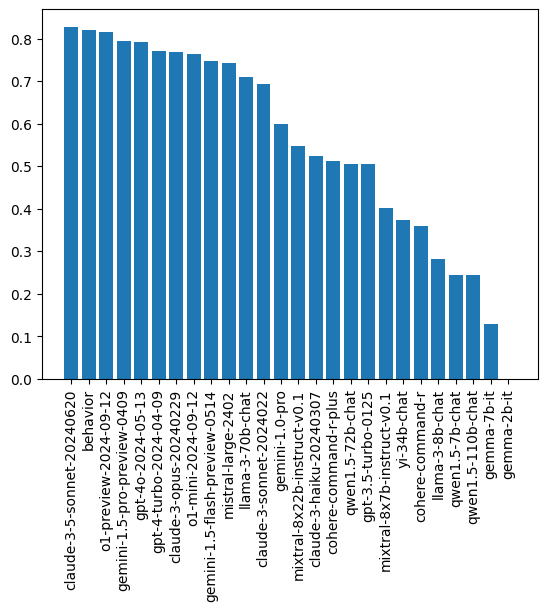

In [ ]:
curr_res = [(key, res["overall"]["overall_confusion_metrics"]["f1_score"]) for key, res in results.items()]
curr_res = sorted(curr_res, key=lambda x: x[1], reverse=True)
all_res[0] = curr_res
plt.bar([x[0] for x in curr_res], [x[1] for x in curr_res])
plt.xticks(rotation=90)
plt.plot()

subgoal_decomposition

In [ ]:
task = tasks[1]
path = f"output/{env}/evaluate_results/{task}/summary"
files = glob.glob(os.path.join(path, f"*.json"))
results = {}
for file in files:
    loaded_data = json.load(open(file, "r"))
    model = file.split("/")[-1].replace(".json", "").split("_")[0]
    results[model] = loaded_data
# Print out the keys of the loaded JSON file to understand its structure
[{k:[{k_: list(v_.keys())} if isinstance(v_, dict) else k_ for k_, v_ in v.items()]} if isinstance(v, dict) else k for k, v in loaded_data.items()]

[{'trajectory_evaluation': ['execution_success_rate',
   {'grammar_error': ['parsing',
     'hallucination',
     'predicate_argument_number']},
   {'runtime_error': ['wrong_order',
     'missing_step',
     'affordance',
     'additional_step']}]},
 {'goal_evaluation': ['task_success_rate',
   'state_goal',
   'relation_goal',
   'action_goal',
   'total_goal']}]

[]

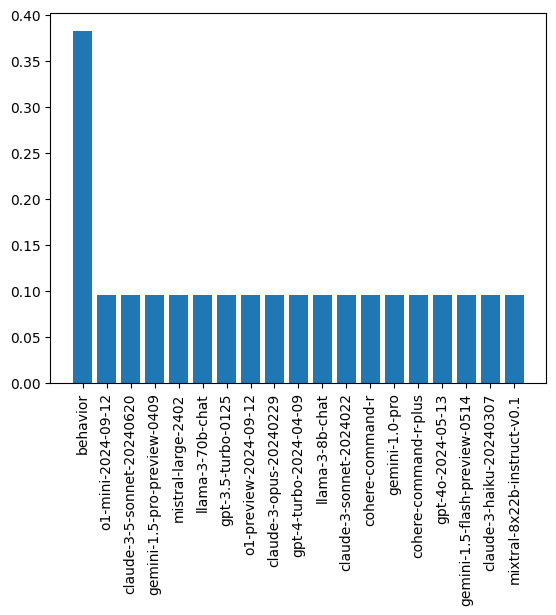

In [ ]:
curr_res = [(key, res["goal_evaluation"]["total_goal"]) for key, res in results.items()]
# curr_res = [(key, res["trajectory_evaluation"]["execution_success_rate"]) for key, res in results.items()]
curr_res = sorted(curr_res, key=lambda x: x[1], reverse=True)
all_res[1] = curr_res
plt.bar([x[0] for x in curr_res], [x[1] for x in curr_res])
plt.xticks(rotation=90)
plt.plot()

action_sequencing

In [ ]:
task = tasks[2]
path = f"output/{env}/evaluate_results/{task}/summary"
files = glob.glob(os.path.join(path, f"*.json"))
results = {}
for file in files:
    loaded_data = json.load(open(file, "r"))
    model = file.split("/")[-1].replace(".json", "").split("_")[0]
    results[model] = loaded_data
# Print out the keys of the loaded JSON file to understand its structure
[{k:[{k_: list(v_.keys())} if isinstance(v_, dict) else k_ for k_, v_ in v.items()]} if isinstance(v, dict) else k for k, v in loaded_data.items()]

[{'goal_evaluation': ['task_success_rate',
   'state_goal',
   'relation_goal',
   'action_goal',
   'total_goal']},
 {'trajectory_evaluation': ['execution_success_rate',
   {'grammar_error': ['parsing',
     'hallucination',
     'predicate_argument_number']},
   {'runtime_error': ['wrong_order',
     'missing_step',
     'affordance',
     'additional_step']}]}]

[]

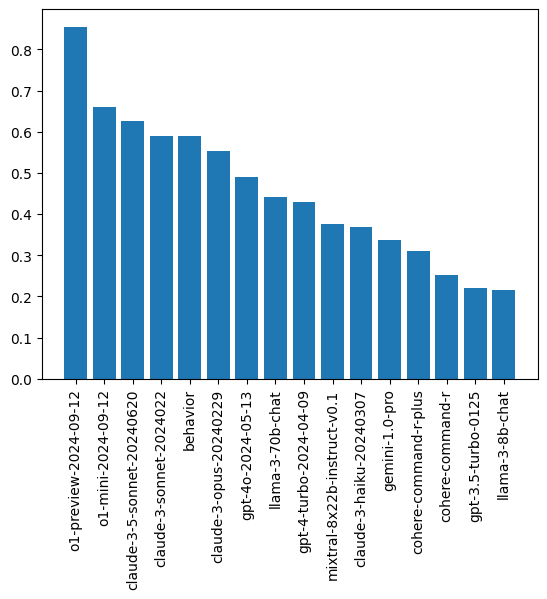

In [ ]:
curr_res = [(key, res["goal_evaluation"]["total_goal"]) for key, res in results.items()]
# curr_res = [(key, res["trajectory_evaluation"]["execution_success_rate"]) for key, res in results.items()]
curr_res = sorted(curr_res, key=lambda x: x[1], reverse=True)
all_res[2] = curr_res
plt.bar([x[0] for x in curr_res], [x[1] for x in curr_res])
plt.xticks(rotation=90)
plt.plot()

transition_modeling

In [ ]:
task = tasks[3]
path = f"output/{env}/evaluate_results/{task}/*"
files = glob.glob(os.path.join(path, f"*.json"))
results = {}
for file in files:
    loaded_data = json.load(open(file, "r"))
    model = file.split("/")[-2].split("_")[0]
    results[model] = loaded_data
# Print out the keys of the loaded JSON file to understand its structure
[{k:[{k_: list(v_.keys())} if isinstance(v_, dict) else k_ for k_, v_ in v.items()]} if isinstance(v, dict) else k for k, v in loaded_data.items()]

[{'non-spatial_relations': ['precision',
   'recall',
   'f1',
   'planner_success_rate']},
 {'spatial_relations': ['precision', 'recall', 'f1', 'planner_success_rate']},
 {'object_states': ['precision', 'recall', 'f1', 'planner_success_rate']},
 {'overall': ['precision', 'recall', 'f1', 'planner_success_rate']}]

[]

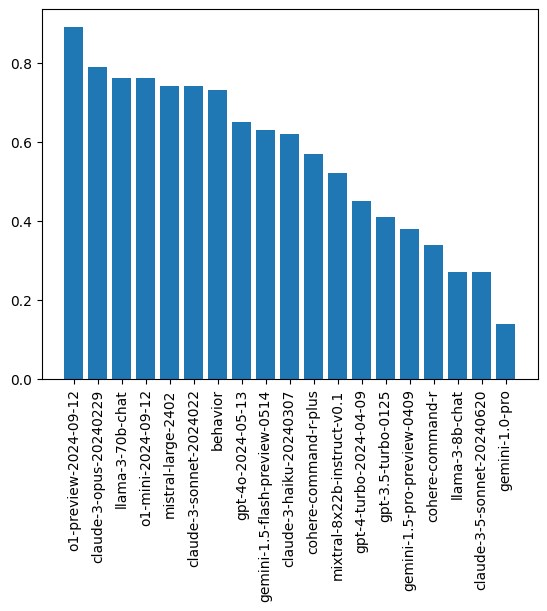

In [ ]:
curr_res = [(key, res["overall"]["planner_success_rate"]/100) for key, res in results.items()]
curr_res = sorted(curr_res, key=lambda x: x[1], reverse=True)
all_res[3] = curr_res
plt.bar([x[0] for x in curr_res], [x[1] for x in curr_res])
plt.xticks(rotation=90)
plt.plot()

All tasks

In [ ]:
all_res

[[('claude-3-5-sonnet-20240620', 0.8273852876911871),
  ('behavior', 0.8207754206291149),
  ('o1-preview-2024-09-12', 0.8161816891412348),
  ('gemini-1.5-pro-preview-0409', 0.7955882352941176),
  ('gpt-4o-2024-05-13', 0.7922636103151861),
  ('gpt-4-turbo-2024-04-09', 0.7714701601164483),
  ('claude-3-opus-20240229', 0.7697642163661581),
  ('o1-mini-2024-09-12', 0.7638691322901849),
  ('gemini-1.5-flash-preview-0514', 0.7479338842975206),
  ('mistral-large-2402', 0.7432525951557094),
  ('llama-3-70b-chat', 0.7088096839273704),
  ('claude-3-sonnet-2024022', 0.6939546599496221),
  ('gemini-1.0-pro', 0.5997552019583843),
  ('mixtral-8x22b-instruct-v0.1', 0.5473204104903078),
  ('claude-3-haiku-20240307', 0.524644030668127),
  ('cohere-command-r-plus', 0.5121951219512196),
  ('qwen1.5-72b-chat', 0.5052083333333333),
  ('gpt-3.5-turbo-0125', 0.5043731778425655),
  ('mixtral-8x7b-instruct-v0.1', 0.402620607504467),
  ('yi-34b-chat', 0.37339556592765466),
  ('cohere-command-r', 0.3597199784598

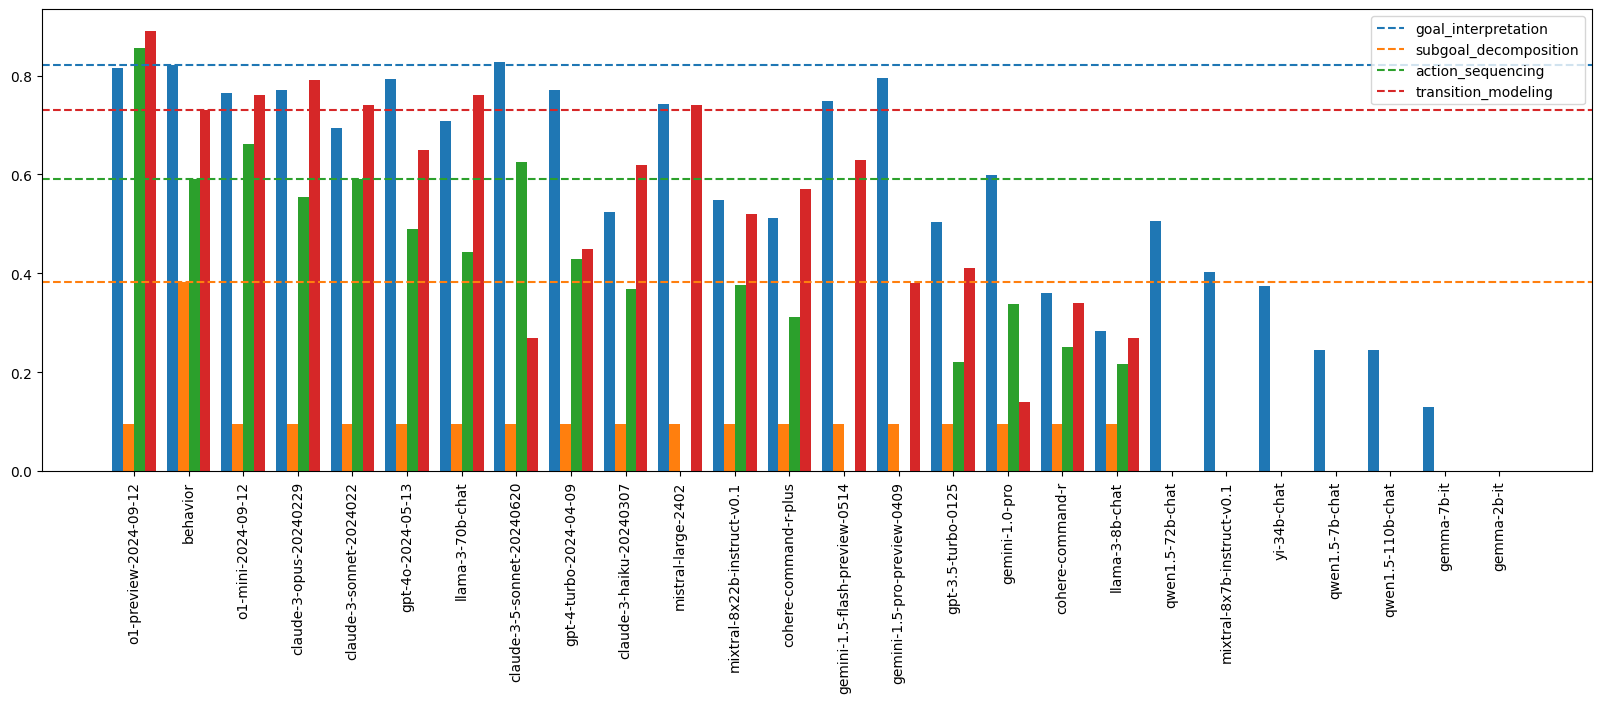

In [ ]:
combined_res = {}
for i, res in enumerate(all_res):
    for k, v in res:
        if k not in combined_res:
            combined_res[k] = [0] * len(tasks)
        combined_res[k][i] = v
combined_res = [(k, sum(v)) for k, v in combined_res.items()]
combined_res = sorted(combined_res, key=lambda x: x[1], reverse=True)
sorted_keys = [x[0] for x in combined_res]

plt.figure(figsize=(20,6))
for i, res in enumerate(all_res):
    res = dict(res)
    plt.bar([j + ((i + 1) / (len(tasks) + 1)) - 0.5 for j in range(len(sorted_keys))], [res[k] if k in res else 0 for k in sorted_keys], width=1/(len(tasks) + 1))
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']
for i, res in enumerate(all_res):
    res = dict(res)
    plt.axhline(res["behavior"], color=colors[i], linestyle='--')
plt.xticks(range(len(sorted_keys)), sorted_keys, rotation=90)
plt.legend(tasks)
plt.show()
